In [1]:
%load_ext autoreload
%autoreload 2

from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx
from torch_geometric.nn import GCNConv, GINConv, GATConv, GATv2Conv
from matplotlib import pyplot as plt
import networkx as nx
import torch

### Phase 0

In [21]:
cora_dataset = Planetoid(root='data', name='Cora')
data = cora_dataset[0]
data.to("cuda")
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

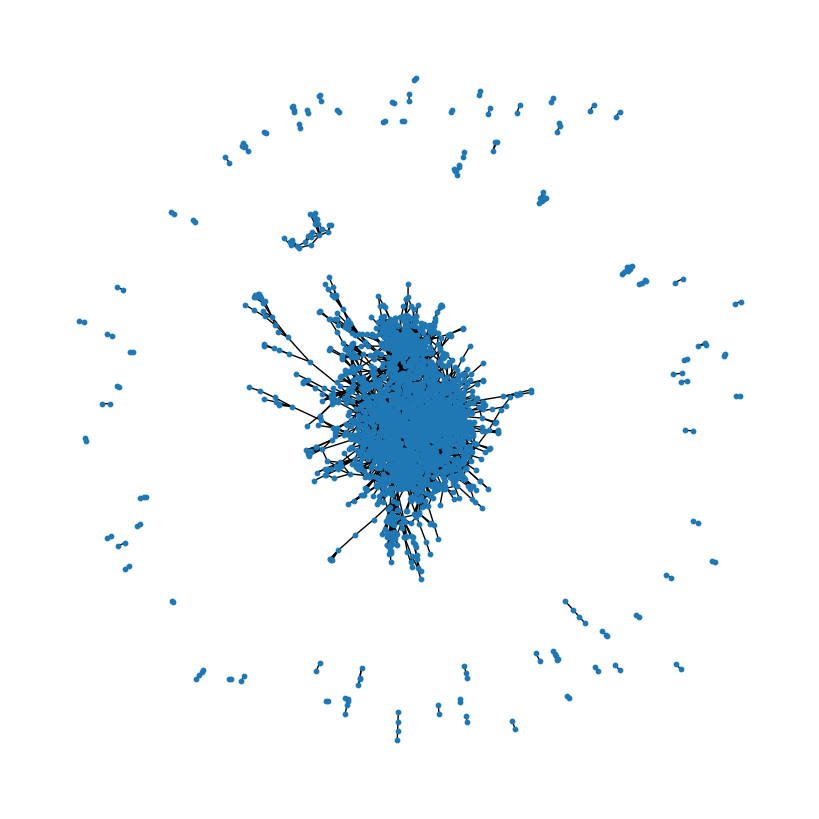

In [ ]:
graph = to_networkx(data, to_undirected=True)

plt.figure(figsize=(8, 8))
nx.draw(graph, node_size=10)
plt.show()

### Phase 1

  2%|▏         | 19/1000 [00:00<00:10, 91.01it/s]

Epoch: 0, Train Loss: 1.963632583618164, Val Loss: 1.9075015783309937


  7%|▋         | 67/1000 [00:00<00:08, 112.00it/s]


Epoch: 50, Train Loss: 0.20694704353809357, Val Loss: 1.839340090751648
Early stopping at epoch 67
Training complete. Best validation loss: 1.237755298614502


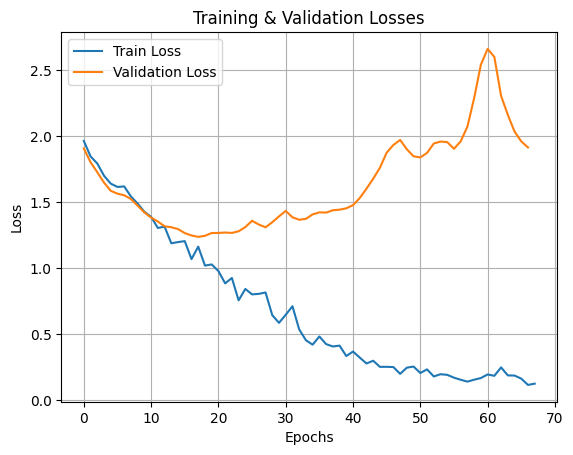

Classification Report:
               precision    recall  f1-score   support

           0      0.400     0.815     0.537       130
           1      0.773     0.824     0.798        91
           2      0.848     0.812     0.830       144
           3      0.896     0.621     0.733       319
           4      0.857     0.725     0.785       149
           5      0.740     0.748     0.744       103
           6      0.816     0.625     0.708        64

    accuracy                          0.721      1000
   macro avg      0.762     0.739     0.734      1000
weighted avg      0.786     0.721     0.735      1000



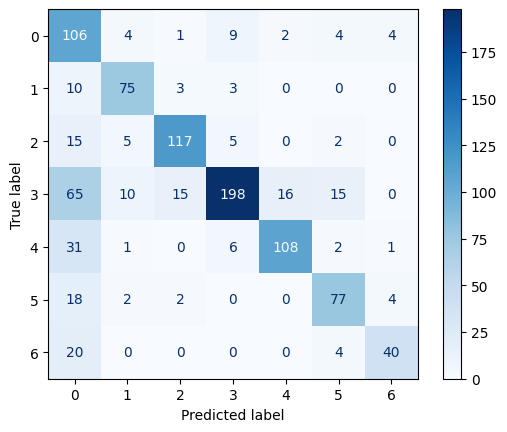

In [ ]:
from train import main

hyperparameters = {
    "learning_rate": 0.0020,
    "epochs": 1000,
    "log_interval": 50,
    "layers": [64, 64],
    "dropout": 0.5,
    "patience": 50,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}
main(GINConv,hyperparameters)

  1%|          | 2/200 [00:00<00:14, 13.40it/s]

Epoch: 0, Train Loss: 1.9460126161575317, Val Loss: 1.9297860860824585


 27%|██▋       | 54/200 [00:02<00:06, 21.13it/s]

Epoch: 50, Train Loss: 0.2624259293079376, Val Loss: 0.6848875880241394


 46%|████▋     | 93/200 [00:04<00:05, 20.39it/s]

Early stopping at epoch 93
Training complete. Best validation loss: 0.627480149269104


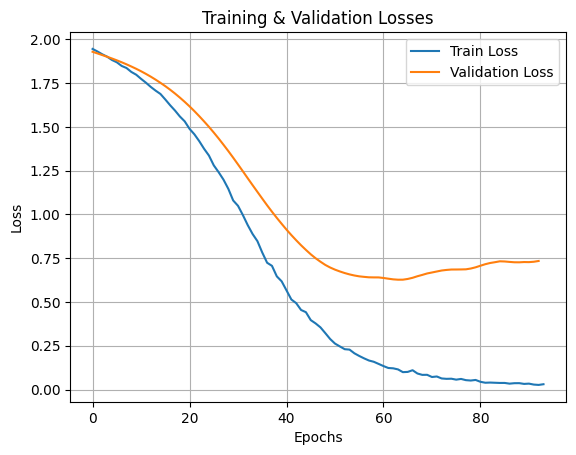

Classification Report:
               precision    recall  f1-score   support

           0      0.688     0.746     0.716       130
           1      0.767     0.868     0.814        91
           2      0.858     0.924     0.890       144
           3      0.904     0.712     0.796       319
           4      0.753     0.879     0.811       149
           5      0.830     0.806     0.818       103
           6      0.711     0.844     0.771        64

    accuracy                          0.804      1000
   macro avg      0.787     0.825     0.802      1000
weighted avg      0.814     0.804     0.804      1000



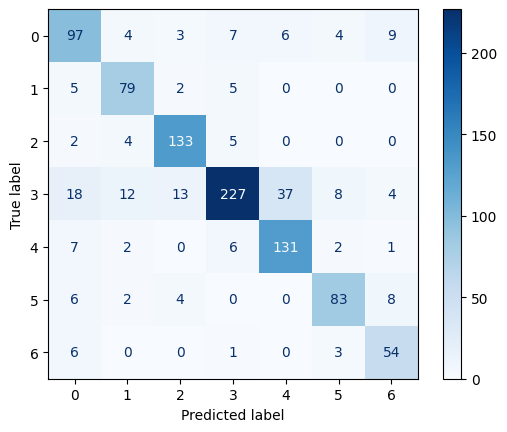

In [ ]:
from train import main

hyperparameters = {
    "learning_rate": 0.0001,
    "epochs": 200,
    "log_interval": 50,
    "layers": [2048, 1024, 512],
    "dropout": 0.5,
    "patience": 30,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}
main(GCNConv,hyperparameters)